In [25]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from csv import QUOTE_NONE
from pathlib import Path
import os
import sys
import csv

In [26]:
data_path = Path(os.path.abspath("")).parents[1]

max_int = sys.maxsize
while True:
    # Decrease the value by factor 10 as long as the OverflowError occurs.
    try:
        csv.field_size_limit(max_int)
        break
    except OverflowError:
        max_int = int(max_int/10)

df = pd.read_csv(data_path / "dataset_creation/data/all_labeled_split_512_randy_twitter_sliced.csv", sep="‎", quoting=QUOTE_NONE)

C:\Users\Jonas\AppData\Local\Temp\ipykernel_21220\1951764451.py:12: ParserWarning: Falling back to the 'python' engine because the separator encoded in utf-8 is > 1 char long, and the 'c' engine does not support such separators; you can avoid this warning by specifying engine='python'.
  df = pd.read_csv(data_path / "dataset_creation/data/all_labeled_split_512_randy_twitter_sliced.csv", sep="‎", quoting=QUOTE_NONE)


In [27]:
value_counts = df["label"].value_counts().to_list()

print(value_counts[1])

3313


[17986, 3313]


C:\Users\Jonas\AppData\Local\Temp\ipykernel_21220\3144541610.py:10: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid') # nice and clean grid


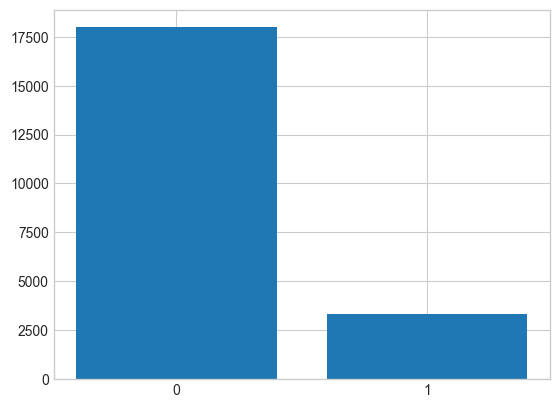

In [28]:
import numpy as np
import seaborn as sns

counts, bins = np.histogram(value_counts)
print([value_counts[0], value_counts[1]])

#plt.hist(counts, 2)
#plt.show()

plt.style.use('seaborn-whitegrid') # nice and clean grid
plt.bar([0,1], value_counts, tick_label=[0,1])
plt.show()

In [29]:
sys.path.append("..")
from utils.word_embeddings import _tokenize_with_preprocessing

# Clean all texts and separate into dataframes

df["text"] = df["text"].map(lambda a: _tokenize_with_preprocessing(a))

shooter_df = df[df["label"] == 1]
non_shooter_df = df[df["label"] == 0]

c:\Users\Jonas\NTNU-Masters\src\experiments\notebooks\..\utils\word_embeddings.py:54: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  soup = BeautifulSoup(text, "html.parser")
c:\Users\Jonas\NTNU-Masters\src\experiments\notebooks\..\utils\word_embeddings.py:54: MarkupResemblesLocatorWarning: The input looks more like a URL than markup. You may want to use an HTTP client like requests to get the document behind the URL, and feed that document to Beautiful Soup.
  soup = BeautifulSoup(text, "html.parser")


In [30]:
from nltk.stem import WordNetLemmatizer

# Lemmatize for input to wordclouds

lemmatizer = WordNetLemmatizer()

def lemmatize_sequence(sentence, lemmatizer):
    out = []
    for word in sentence:
        out.append(lemmatizer.lemmatize(word))

    return out


#shooter_df["text"] = shooter_df["text"].map(lambda a: lemmatize_sequence(a, lemmatizer))
#non_shooter_df["text"] = non_shooter_df["text"].map(lambda a: lemmatize_sequence(a, lemmatizer))


In [31]:
# Concat all df rows to generate collection of words

def flatten_array(arr):
    flat_array = []
    for row in arr:
        for word in row:
            flat_array.append(word)
    
    return flat_array

shooter_flat_collection = flatten_array(shooter_df["text"])
non_shooter_flat_collection = flatten_array(non_shooter_df["text"])

In [32]:
from wordcloud import WordCloud
import requests
from PIL import Image


pic = np.array(Image.open(requests.get('https://static.vecteezy.com/system/resources/previews/001/199/082/original/gun-png.png',stream=True).raw))

wordcloud = WordCloud(width = 800, height = 800, 
                background_color ='white', mask = pic, 
                min_font_size = 10).generate(" ".join(shooter_flat_collection))

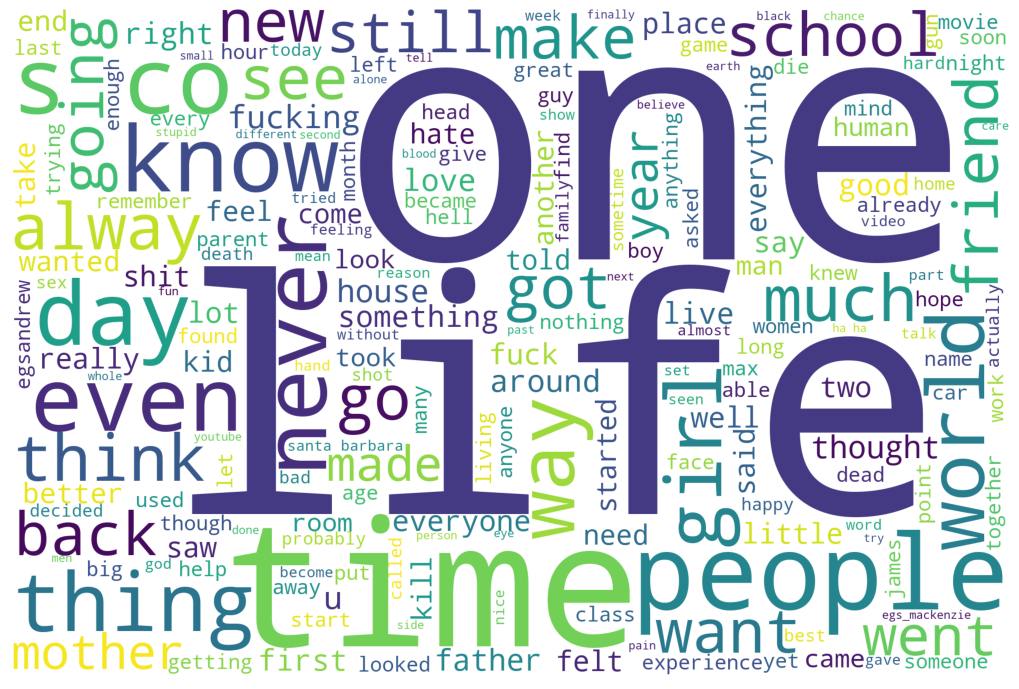

In [33]:
plt.figure(figsize = (10, 10), facecolor = 'white', edgecolor='blue') 
plt.imshow(wordcloud) 
plt.axis("off") 
plt.tight_layout(pad = 0) 
  
plt.show()

In [37]:
non_shooter_wordcloud = WordCloud(width = 800, height = 800, 
                background_color ='white', mask = pic, 
                min_font_size = 10, stopwords=["propname"]).generate(" ".join(non_shooter_flat_collection))

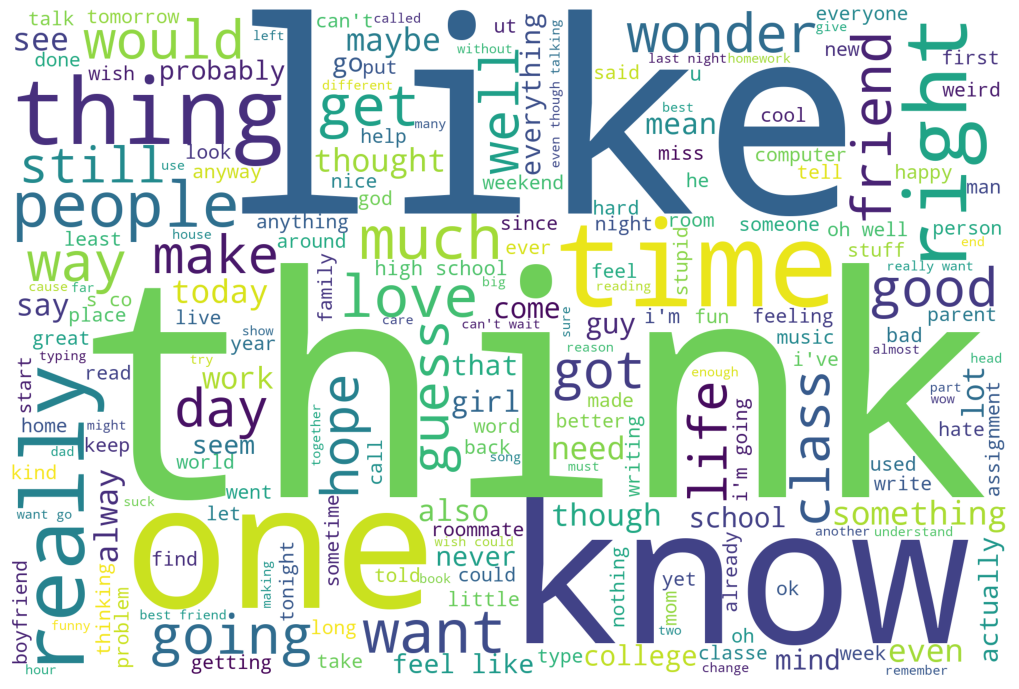

In [38]:
plt.figure(figsize = (10, 10), facecolor = 'white', edgecolor='blue') 
plt.imshow(non_shooter_wordcloud) 
plt.axis("off") 
plt.tight_layout(pad = 0) 
  
plt.show()

In [34]:
from sklearn.feature_extraction.text import CountVectorizer

def same_tokens(tokens):
    # Wrapper function to allow for tokens to be passed to the CountVectorizer
    return tokens


cv1 = CountVectorizer(
        tokenizer=same_tokens,
        preprocessor=same_tokens,
    )

cv2 = CountVectorizer(
        tokenizer=same_tokens,
        preprocessor=same_tokens,
    )

# Count word occurences
shooter_word_counts = cv1.fit_transform(shooter_df["text"].values)
non_shooter_word_counts = cv2.fit_transform(non_shooter_df["text"].values)

print(cv1.get_feature_names_out())

c:\Users\Jonas\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_extraction\text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


["'" "''" "'86" ... 'zyv5hxbtau' 'zzfagl8vbv' 'ô']
